# S&P 500 Clustering Pipeline
Single notebook with feature-case tuning, **k selection**, temporal stability evaluation (train → validation → test), and **mean + std aggregation** per stock.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

## 2. Load Data

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Symbol', 'Date']).copy()

print("Min date:", df['Date'].min())
print("Max date:", df['Date'].max())
print("Rows:", len(df))
print("Stocks:", df['Symbol'].nunique())
df.head()

Min date: 2021-03-22 00:00:00
Max date: 2026-03-20 00:00:00
Rows: 626169
Stocks: 503


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005


## 3. Time-based Split (3y / 1y / 1y)

In [3]:
train = df[(df['Date'] >= '2021-03-22') & (df['Date'] <= '2024-03-21')].copy()
val   = df[(df['Date'] >= '2024-03-22') & (df['Date'] <= '2025-03-21')].copy()
test  = df[(df['Date'] >= '2025-03-22') & (df['Date'] <= '2026-03-21')].copy()

print("Train rows:", len(train))
print("Validation rows:", len(val))
print("Test rows:", len(test))

Train rows: 375299
Validation rows: 125271
Test rows: 125599


## 4. Keep Only Stocks Available in All 3 Splits

In [4]:
common_symbols = (
    set(train['Symbol'].unique())
    & set(val['Symbol'].unique())
    & set(test['Symbol'].unique())
)

train = train[train['Symbol'].isin(common_symbols)].copy()
val   = val[val['Symbol'].isin(common_symbols)].copy()
test  = test[test['Symbol'].isin(common_symbols)].copy()

print("Common stocks:", len(common_symbols))
print("Train stocks:", train['Symbol'].nunique())
print("Validation stocks:", val['Symbol'].nunique())
print("Test stocks:", test['Symbol'].nunique())

Common stocks: 499
Train stocks: 499
Validation stocks: 499
Test stocks: 499


## 5. Feature Engineering

In [24]:
def create_features(df):
    df = df.copy()
    df['log_close'] = np.log(df['Close'])

    # Returns
    df['logret_1'] = df.groupby('Symbol')['log_close'].diff(1)
    df['logret_5'] = df.groupby('Symbol')['log_close'].diff(5)
    df['logret_21'] = df.groupby('Symbol')['log_close'].diff(21)

    # Matched volatility windows
    df['logvol_1'] = df.groupby('Symbol')['logret_1'].rolling(2).std().reset_index(level=0, drop=True)
    df['logvol_5'] = df.groupby('Symbol')['logret_1'].rolling(5).std().reset_index(level=0, drop=True)
    df['logvol_21'] = df.groupby('Symbol')['logret_1'].rolling(21).std().reset_index(level=0, drop=True)

    # Volume feature
    df['log_volume'] = np.log(df['Volume'].clip(lower=1))
    df['vol_chg'] = df.groupby('Symbol')['log_volume'].diff()

    return df

train = create_features(train)
val   = create_features(val)
test  = create_features(test)

train.head()

,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,Weight,log_close,logret_1,logret_5,logret_21,logvol_1,logvol_5,logvol_21,log_volume,vol_chg
11304,2021-03-22,118.071328,119.675641,117.636428,119.463020,1772900,A,Agilent Technologies,Health Care,0.0005,4.783007,NaN,NaN,NaN,NaN,NaN,NaN,14.388127,NaN
11305,2021-03-23,119.018449,120.062218,117.394811,117.887703,1338300,A,Agilent Technologies,Health Care,0.0005,4.769733,-0.013274,NaN,NaN,NaN,NaN,NaN,14.106911,-0.281216
11306,2021-03-24,118.022998,118.834813,116.689291,116.785934,1477500,A,Agilent Technologies,Health Care,0.0005,4.760343,-0.009390,NaN,NaN,0.002747,NaN,NaN,14.205862,0.098951
11307,2021-03-25,116.805284,118.225969,115.858159,117.810394,967300,A,Agilent Technologies,Health Care,0.0005,4.769077,0.008734,NaN,NaN,0.012815,NaN,NaN,13.782264,-0.423598
11308,2021-03-26,118.428900,121.492548,117.936008,121.424896,1441900,A,Agilent Technologies,Health Care,0.0005,4.799296,0.030219,NaN,NaN,0.015193,NaN,NaN,14.181472,0.399208


## 6. Define Feature Cases

In [6]:
FEATURE_CASES = {
    "case_1": ['logret_1', 'logvol_1', 'vol_chg', 'Weight'],
    "case_2": ['logret_5', 'logvol_5', 'vol_chg', 'Weight'],
    "case_3": ['logret_21', 'logvol_21', 'vol_chg', 'Weight']
}

FEATURE_CASES

{'case_1': ['logret_1', 'logvol_1', 'vol_chg', 'Weight'],
 'case_2': ['logret_5', 'logvol_5', 'vol_chg', 'Weight'],
 'case_3': ['logret_21', 'logvol_21', 'vol_chg', 'Weight']}

## 7. Aggregate Daily Features to One Vector Per Stock
Each stock is represented by:
- the **mean** of every selected feature
- the **standard deviation** of time-varying features

`Weight` keeps only its mean, since its standard deviation is not informative for a stock-level summary.

In [7]:
def aggregate_features(df, feature_cols):
    # Mean of all selected features
    agg_mean = df.groupby('Symbol')[feature_cols].mean()

    # Standard deviation only for time-varying features
    cols_for_std = [col for col in feature_cols if col != 'Weight']
    agg_std = df.groupby('Symbol')[cols_for_std].std()
    agg_std.columns = [f"{col}_std" for col in agg_std.columns]

    # Combine mean + std
    X = pd.concat([agg_mean, agg_std], axis=1)

    return X.dropna()

## 8. KMeans Helper Functions

In [8]:
def fit_kmeans(X, k):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)

    return model, scaler, labels, score, X_scaled

def apply_kmeans(X, model, scaler):
    X_scaled = scaler.transform(X)
    labels = model.predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    return labels, score, X_scaled

def evaluate_k_range(X, k_range=range(2, 9)):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    rows = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        inertia = model.inertia_

        rows.append({
            "k": k,
            "silhouette": sil,
            "inertia": inertia
        })

    return pd.DataFrame(rows), X_scaled

## 9. Compare Feature Cases on Training Set
For each feature case, search over candidate `k` values and keep the best silhouette score.

In [9]:
feature_case_results = []

for case_name, feature_cols in FEATURE_CASES.items():
    X_train_case = aggregate_features(train, feature_cols)
    k_results_case, _ = evaluate_k_range(X_train_case, k_range=range(2, 9))

    best_idx = k_results_case['silhouette'].idxmax()
    best_k_case = int(k_results_case.loc[best_idx, 'k'])
    best_sil_case = float(k_results_case.loc[best_idx, 'silhouette'])

    feature_case_results.append({
        "case": case_name,
        "features": ", ".join(feature_cols),
        "n_stocks": len(X_train_case),
        "aggregated_feature_count": X_train_case.shape[1],
        "best_k": best_k_case,
        "best_train_silhouette": best_sil_case
    })

feature_case_results_df = (
    pd.DataFrame(feature_case_results)
    .sort_values("best_train_silhouette", ascending=False)
    .reset_index(drop=True)
)

feature_case_results_df

,case,features,n_stocks,aggregated_feature_count,best_k,best_train_silhouette
0,case_2,"logret_5, logvol_5, vol_chg, Weight",499,7,2,0.536017
1,case_3,"logret_21, logvol_21, vol_chg, Weight",499,7,2,0.531304
2,case_1,"logret_1, logvol_1, vol_chg, Weight",499,7,2,0.509296


## 10. Select Best Feature Case

In [10]:
best_case = feature_case_results_df.loc[0, 'case']
best_features = FEATURE_CASES[best_case]

print("Best feature case:", best_case)
print("Selected raw features:", best_features)

Best feature case: case_2
Selected raw features: ['logret_5', 'logvol_5', 'vol_chg', 'Weight']


## 11. Build Final Training Matrix

In [11]:
X_train = aggregate_features(train, best_features)

print("Training matrix shape:", X_train.shape)
print("Aggregated columns:")
print(list(X_train.columns))

X_train.head()

Training matrix shape: (499, 7)
Aggregated columns:
['logret_5', 'logvol_5', 'vol_chg', 'Weight', 'logret_5_std', 'logvol_5_std', 'vol_chg_std']


,logret_5,logvol_5,vol_chg,Weight,logret_5_std,logvol_5_std,vol_chg_std
Symbol,,,,,,,
A,0.001344,0.016169,-0.000157,0.0005,0.037823,0.007830,0.378155
AAPL,0.002521,0.015094,-0.000070,0.0618,0.036398,0.007837,0.252366
ABBV,0.004346,0.011032,-0.000376,0.0062,0.028523,0.006114,0.380993
ABNB,-0.000723,0.027953,0.000623,0.0013,0.067800,0.013818,0.412775
ABT,-0.000073,0.012475,0.000836,0.0031,0.031515,0.006591,0.333946


## 12. Select the Number of Clusters (k)
Use **silhouette score** as the main criterion and **inertia** as supporting evidence.

In [12]:
k_results, _ = evaluate_k_range(X_train, k_range=range(2, 9))
k_results

,k,silhouette,inertia
0,2,0.536017,2667.408983
1,3,0.478418,2204.538424
2,4,0.489284,1840.884570
3,5,0.316981,1500.447371
4,6,0.324896,1315.339180
5,7,0.320159,1161.362064
6,8,0.306155,1046.866957


## 13. Plot Silhouette and Elbow Curves

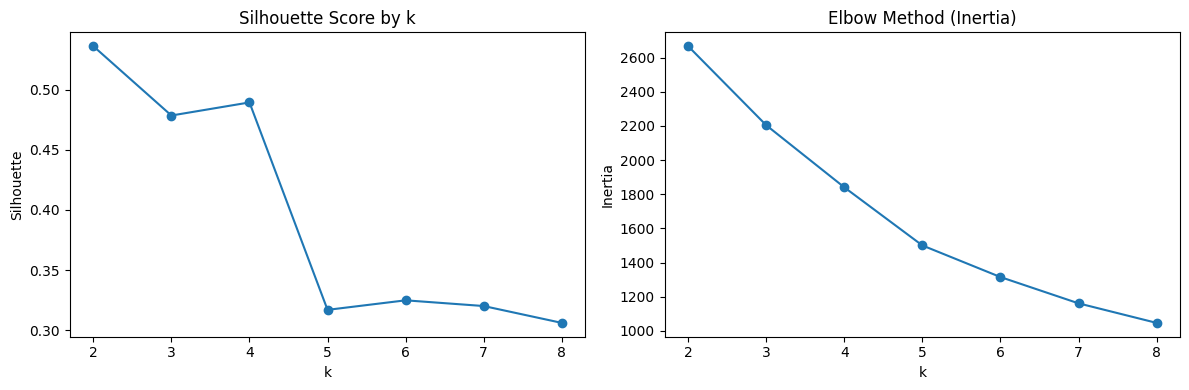

In [13]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_results['k'], k_results['silhouette'], marker='o')
plt.title("Silhouette Score by k")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.subplot(1, 2, 2)
plt.plot(k_results['k'], k_results['inertia'], marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

## 14. Choose Best k

In [14]:
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
print("Selected k:", best_k)

Selected k: 2


## 15. Fit Final Clustering on Train

In [15]:
model, scaler, train_labels, train_score, X_train_scaled = fit_kmeans(X_train, k=best_k)

train_clusters = pd.DataFrame({
    "Symbol": X_train.index,
    "Cluster_train": train_labels
})

print("Train silhouette:", round(train_score, 4))
train_clusters.head()

Train silhouette: 0.536


,Symbol,Cluster_train
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,1
4,ABT,0


## 16. Evaluate Cluster Stability on Validation

In [16]:
X_val = aggregate_features(val, best_features)

common_train_val = X_train.index.intersection(X_val.index)
X_val = X_val.loc[common_train_val]

val_labels, val_score, X_val_scaled = apply_kmeans(X_val, model, scaler)

val_clusters = pd.DataFrame({
    "Symbol": X_val.index,
    "Cluster_val": val_labels
})

print("Validation silhouette:", round(val_score, 4))
val_clusters.head()

Validation silhouette: 0.3943


,Symbol,Cluster_val
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 17. Confirm Cluster Stability on Test

In [17]:
X_test = aggregate_features(test, best_features)

common_train_test = X_train.index.intersection(X_test.index)
X_test = X_test.loc[common_train_test]

test_labels, test_score, X_test_scaled = apply_kmeans(X_test, model, scaler)

test_clusters = pd.DataFrame({
    "Symbol": X_test.index,
    "Cluster_test": test_labels
})

print("Test silhouette:", round(test_score, 4))
test_clusters.head()

Test silhouette: 0.2785


,Symbol,Cluster_test
0,A,0
1,AAPL,0
2,ABBV,0
3,ABNB,0
4,ABT,0


## 18. Stability Summary

In [18]:
stability_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "silhouette": [train_score, val_score, test_score]
})

stability_summary

,split,silhouette
0,train,0.536017
1,validation,0.394314
2,test,0.278539


## 19. Same-Stock Cluster Consistency

In [19]:
train_val_compare = train_clusters.merge(val_clusters, on="Symbol", how="inner")
train_test_compare = train_clusters.merge(test_clusters, on="Symbol", how="inner")

train_val_consistency = (train_val_compare["Cluster_train"] == train_val_compare["Cluster_val"]).mean()
train_test_consistency = (train_test_compare["Cluster_train"] == train_test_compare["Cluster_test"]).mean()

print("Train vs Validation consistency:", round(train_val_consistency, 4))
print("Train vs Test consistency:", round(train_test_consistency, 4))

Train vs Validation consistency: 0.8798
Train vs Test consistency: 0.8337


## 20. Cluster Profiles on Training Set

In [20]:
train_profile = X_train.copy()
train_profile["Cluster"] = train_labels

cluster_profile = train_profile.groupby("Cluster").mean()
cluster_profile

,logret_5,logvol_5,vol_chg,Weight,logret_5_std,logvol_5_std,vol_chg_std
Cluster,,,,,,,
0,0.001861,0.015556,-0.000014,0.001855,0.038644,0.008316,0.376172
1,0.000222,0.029019,-0.000117,0.003060,0.074947,0.017219,0.460457


## 21. PCA Visualization of Training Clusters

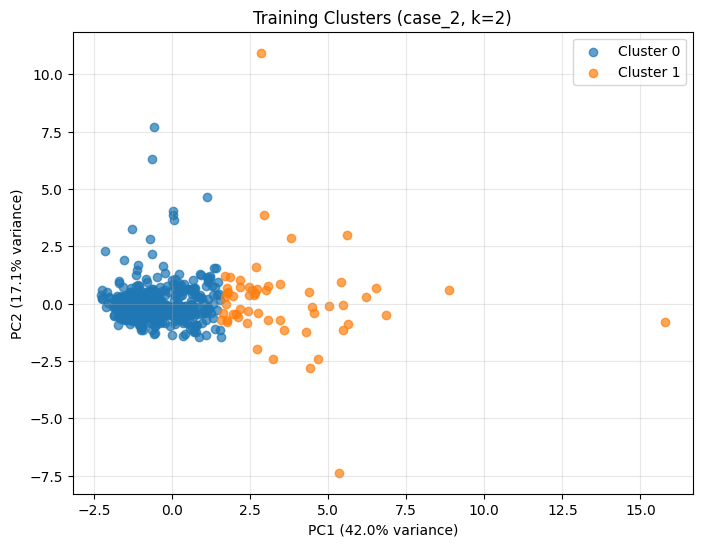

In [29]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Explained variance
explained = pca.explained_variance_ratio_

plt.figure(figsize=(8, 6))

# Plot each cluster separately for proper labels
for cluster in np.unique(train_labels):
    mask = train_labels == cluster
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title(f"Training Clusters ({best_case}, k={best_k})")

# Better axis labels with variance explained
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% variance)")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
pd.Series(train_labels).value_counts()

0    442
1     57
Name: count, dtype: int64

## 22. Final Cluster Assignment Table

In [22]:
final_clusters = (
    train_clusters
    .merge(val_clusters, on="Symbol", how="left")
    .merge(test_clusters, on="Symbol", how="left")
)

final_clusters.head()

,Symbol,Cluster_train,Cluster_val,Cluster_test
0,A,0,0,0
1,AAPL,0,0,0
2,ABBV,0,0,0
3,ABNB,1,0,0
4,ABT,0,0,0


## 23. Optional Export

In [ ]:
# Uncomment if you want to save outputs
# feature_case_results_df.to_csv("feature_case_results.csv", index=False)
# k_results.to_csv("k_selection_results.csv", index=False)
# stability_summary.to_csv("cluster_stability_summary.csv", index=False)
# cluster_profile.to_csv("cluster_profile.csv")
# final_clusters.to_csv("final_cluster_assignments.csv", index=False)

In [26]:
val = val.copy()

val['future_vol_21'] = (
    val.groupby('Symbol')['logret_1']
    .rolling(21)
    .std()
    .shift(-21)
    .reset_index(level=0, drop=True)
)

val = val.dropna(subset=['future_vol_21'])

In [27]:
# Merge cluster labels back
cluster_map = train_clusters.set_index("Symbol")

val_eval = val.copy()
val_eval = val_eval.merge(cluster_map, left_on="Symbol", right_index=True)

# Compare future volatility
val_eval.groupby("Cluster_train")['future_vol_21'].mean()

Cluster_train
0    0.016097
1    0.027464
Name: future_vol_21, dtype: float64

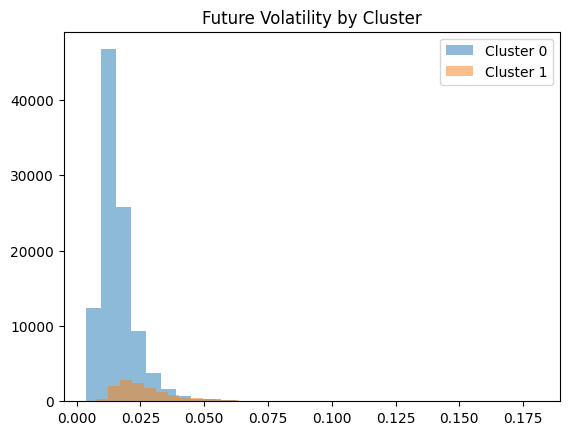

In [28]:
import matplotlib.pyplot as plt

for c in val_eval['Cluster_train'].unique():
    subset = val_eval[val_eval['Cluster_train'] == c]
    plt.hist(subset['future_vol_21'], bins=30, alpha=0.5, label=f'Cluster {c}')

plt.legend()
plt.title("Future Volatility by Cluster")
plt.show()